##  Data Acquisiton, Cleaning, and Feature Engineering 


## 1. Load Dataset

In [29]:
import pandas as pd
import numpy as np

df = pd.read_csv('hotel_bookings_resort.csv')
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [30]:
df.describe()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,BookingChanges,DaysInWaitingList,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests
count,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.00000
mean,0.277634,92.675686,2016.121443,27.140864,15.821243,1.189815,3.128732,1.867149,0.128682,0.013904,0.044383,0.101722,0.146455,0.287968,0.527758,94.952930,0.138068,0.61977
std,0.447837,97.285315,0.722347,14.005441,8.883708,1.147812,2.461329,0.697285,0.445195,0.118998,0.205948,1.335115,1.001955,0.726548,7.428580,61.442418,0.351001,0.81393
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.00000
25%,0.000000,10.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.00000
50%,0.000000,57.000000,2016.000000,28.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,75.000000,0.000000,0.00000
75%,1.000000,155.000000,2017.000000,38.000000,24.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,125.000000,0.000000,1.00000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,2.000000,1.000000,26.000000,30.000000,17.000000,185.000000,508.000000,8.000000,5.00000


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40060 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   40060 non-null  int64  
 1   LeadTime                     40060 non-null  int64  
 2   ArrivalDateYear              40060 non-null  int64  
 3   ArrivalDateMonth             40060 non-null  str    
 4   ArrivalDateWeekNumber        40060 non-null  int64  
 5   ArrivalDateDayOfMonth        40060 non-null  int64  
 6   StaysInWeekendNights         40060 non-null  int64  
 7   StaysInWeekNights            40060 non-null  int64  
 8   Adults                       40060 non-null  int64  
 9   Children                     40060 non-null  int64  
 10  Babies                       40060 non-null  int64  
 11  Meal                         40060 non-null  str    
 12  Country                      39596 non-null  str    
 13  MarketSegment              

## 2. Handle 'NULL' Text Values

In [32]:
# Strip spaces
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Replace NULL-like values
null_values = ['NULL', 'null', 'NaN', 'nan', 'None', '']
df = df.replace(null_values, np.nan)

df.isnull().sum()

IsCanceled                       0
LeadTime                         0
ArrivalDateYear                  0
ArrivalDateMonth                 0
ArrivalDateWeekNumber            0
ArrivalDateDayOfMonth            0
StaysInWeekendNights             0
StaysInWeekNights                0
Adults                           0
Children                         0
Babies                           0
Meal                             0
Country                        464
MarketSegment                    0
DistributionChannel              0
IsRepeatedGuest                  0
PreviousCancellations            0
PreviousBookingsNotCanceled      0
ReservedRoomType                 0
AssignedRoomType                 0
BookingChanges                   0
DepositType                      0
Agent                            0
Company                          0
DaysInWaitingList                0
CustomerType                     0
ADR                              0
RequiredCarParkingSpaces         0
TotalOfSpecialReques

In [36]:
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40060 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   40060 non-null  int64  
 1   LeadTime                     40060 non-null  int64  
 2   ArrivalDateYear              40060 non-null  int64  
 3   ArrivalDateMonth             40060 non-null  str    
 4   ArrivalDateWeekNumber        40060 non-null  int64  
 5   ArrivalDateDayOfMonth        40060 non-null  int64  
 6   StaysInWeekendNights         40060 non-null  int64  
 7   StaysInWeekNights            40060 non-null  int64  
 8   Adults                       40060 non-null  int64  
 9   Children                     40060 non-null  int64  
 10  Babies                       40060 non-null  int64  
 11  Meal                         40060 non-null  str    
 12  Country                      40060 non-null  str    
 13  MarketSegment              

## 3. Missing Value Treatment

In [64]:
cat_cols = df.select_dtypes(include=['object', 'str']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [39]:
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40060 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   40060 non-null  int64  
 1   LeadTime                     40060 non-null  int64  
 2   ArrivalDateYear              40060 non-null  int64  
 3   ArrivalDateMonth             40060 non-null  str    
 4   ArrivalDateWeekNumber        40060 non-null  int64  
 5   ArrivalDateDayOfMonth        40060 non-null  int64  
 6   StaysInWeekendNights         40060 non-null  int64  
 7   StaysInWeekNights            40060 non-null  int64  
 8   Adults                       40060 non-null  int64  
 9   Children                     40060 non-null  int64  
 10  Babies                       40060 non-null  int64  
 11  Meal                         40060 non-null  str    
 12  Country                      40060 non-null  str    
 13  MarketSegment              

## 4. Remove Duplicates

In [41]:
df = df.drop_duplicates()

In [24]:
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [42]:
df.info()

<class 'pandas.DataFrame'>
Index: 33949 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   33949 non-null  int64  
 1   LeadTime                     33949 non-null  int64  
 2   ArrivalDateYear              33949 non-null  int64  
 3   ArrivalDateMonth             33949 non-null  str    
 4   ArrivalDateWeekNumber        33949 non-null  int64  
 5   ArrivalDateDayOfMonth        33949 non-null  int64  
 6   StaysInWeekendNights         33949 non-null  int64  
 7   StaysInWeekNights            33949 non-null  int64  
 8   Adults                       33949 non-null  int64  
 9   Children                     33949 non-null  int64  
 10  Babies                       33949 non-null  int64  
 11  Meal                         33949 non-null  str    
 12  Country                      33949 non-null  str    
 13  MarketSegment                339

## 5. Fix Data Types

In [43]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        pass


In [ ]:
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 6.Standardize Column Names

In [44]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [45]:
df.head()

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,deposittype,agent,company,daysinwaitinglist,customertype,adr,requiredcarparkingspaces,totalofspecialrequests,reservationstatus,reservationstatusdate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 33949 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   iscanceled                   33949 non-null  int64  
 1   leadtime                     33949 non-null  int64  
 2   arrivaldateyear              33949 non-null  int64  
 3   arrivaldatemonth             33949 non-null  str    
 4   arrivaldateweeknumber        33949 non-null  int64  
 5   arrivaldatedayofmonth        33949 non-null  int64  
 6   staysinweekendnights         33949 non-null  int64  
 7   staysinweeknights            33949 non-null  int64  
 8   adults                       33949 non-null  int64  
 9   children                     33949 non-null  int64  
 10  babies                       33949 non-null  int64  
 11  meal                         33949 non-null  str    
 12  country                      33949 non-null  str    
 13  marketsegment                339

In [47]:
df['reservationstatusdate'] = pd.to_datetime(
    df['reservationstatusdate'],
    format='%Y-%m-%d',   # enforce correct format
    errors='coerce'
)

In [48]:
df.info()

<class 'pandas.DataFrame'>
Index: 33949 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   iscanceled                   33949 non-null  int64         
 1   leadtime                     33949 non-null  int64         
 2   arrivaldateyear              33949 non-null  int64         
 3   arrivaldatemonth             33949 non-null  str           
 4   arrivaldateweeknumber        33949 non-null  int64         
 5   arrivaldatedayofmonth        33949 non-null  int64         
 6   staysinweekendnights         33949 non-null  int64         
 7   staysinweeknights            33949 non-null  int64         
 8   adults                       33949 non-null  int64         
 9   children                     33949 non-null  int64         
 10  babies                       33949 non-null  int64         
 11  meal                         33949 non-null  str         

In [49]:
df.head()

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,deposittype,agent,company,daysinwaitinglist,customertype,adr,requiredcarparkingspaces,totalofspecialrequests,reservationstatus,reservationstatusdate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 6. Feature Engineering

In [50]:
df['totalstay'] = df['staysinweeknights'] + df['staysinweekendnights']

In [51]:
df['res_year'] = df['reservationstatusdate'].dt.year
df['res_month'] = df['reservationstatusdate'].dt.month
df['res_day'] = df['reservationstatusdate'].dt.day
df['res_weekday'] = df['reservationstatusdate'].dt.weekday

In [52]:
df['pricepernight'] = df['adr'] / (df['staysinweekendnights'] + 1)

In [53]:
df.head()

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,requiredcarparkingspaces,totalofspecialrequests,reservationstatus,reservationstatusdate,totalstay,res_year,res_month,res_day,res_weekday,pricepernight
0,0,342,2015,July,27,1,0,0,2,0,...,0,0,Check-Out,2015-07-01,0,2015,7,1,2,0.0
1,0,737,2015,July,27,1,0,0,2,0,...,0,0,Check-Out,2015-07-01,0,2015,7,1,2,0.0
2,0,7,2015,July,27,1,0,1,1,0,...,0,0,Check-Out,2015-07-02,1,2015,7,2,3,75.0
3,0,13,2015,July,27,1,0,1,1,0,...,0,0,Check-Out,2015-07-02,1,2015,7,2,3,75.0
4,0,14,2015,July,27,1,0,2,2,0,...,0,1,Check-Out,2015-07-03,2,2015,7,3,4,98.0


In [54]:
df.info()

<class 'pandas.DataFrame'>
Index: 33949 entries, 0 to 40059
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   iscanceled                   33949 non-null  int64         
 1   leadtime                     33949 non-null  int64         
 2   arrivaldateyear              33949 non-null  int64         
 3   arrivaldatemonth             33949 non-null  str           
 4   arrivaldateweeknumber        33949 non-null  int64         
 5   arrivaldatedayofmonth        33949 non-null  int64         
 6   staysinweekendnights         33949 non-null  int64         
 7   staysinweeknights            33949 non-null  int64         
 8   adults                       33949 non-null  int64         
 9   children                     33949 non-null  int64         
 10  babies                       33949 non-null  int64         
 11  meal                         33949 non-null  str         

## 8. Outlier Removal (IQR Method)

In [55]:
# Remove negative ADR (invalid)
df_cleanednegative = df[df['adr'] >= 0]


In [56]:
df_cleanednegative.info()

<class 'pandas.DataFrame'>
Index: 33948 entries, 0 to 40059
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   iscanceled                   33948 non-null  int64         
 1   leadtime                     33948 non-null  int64         
 2   arrivaldateyear              33948 non-null  int64         
 3   arrivaldatemonth             33948 non-null  str           
 4   arrivaldateweeknumber        33948 non-null  int64         
 5   arrivaldatedayofmonth        33948 non-null  int64         
 6   staysinweekendnights         33948 non-null  int64         
 7   staysinweeknights            33948 non-null  int64         
 8   adults                       33948 non-null  int64         
 9   children                     33948 non-null  int64         
 10  babies                       33948 non-null  int64         
 11  meal                         33948 non-null  str         

In [57]:
df_cleanednegative['adr'].max()

np.float64(508.0)

In [58]:
Q1 = df_cleanednegative['adr'].quantile(0.25)
Q3 = df_cleanednegative['adr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower, "Upper:", upper)

Lower: -72.39999999999999 Upper: 258.0


In [59]:
upper = df_cleanednegative['adr'].quantile(0.99)
lower = df_cleanednegative['adr'].quantile(0.01)

df_cleanednegative['adr'] = df_cleanednegative['adr'].clip(lower, upper)


In [60]:
# Optional: normalize
df_cleanednegative['adr_log'] = np.log1p(df_cleanednegative['adr'])

In [61]:
df_cleanednegative

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,totalofspecialrequests,reservationstatus,reservationstatusdate,totalstay,res_year,res_month,res_day,res_weekday,pricepernight,adr_log
0,0,342,2015,July,27,1,0,0,2,0,...,0,Check-Out,2015-07-01,0,2015,7,1,2,0.000000,0.000000
1,0,737,2015,July,27,1,0,0,2,0,...,0,Check-Out,2015-07-01,0,2015,7,1,2,0.000000,0.000000
2,0,7,2015,July,27,1,0,1,1,0,...,0,Check-Out,2015-07-02,1,2015,7,2,3,75.000000,4.330733
3,0,13,2015,July,27,1,0,1,1,0,...,0,Check-Out,2015-07-02,1,2015,7,2,3,75.000000,4.330733
4,0,14,2015,July,27,1,0,2,2,0,...,1,Check-Out,2015-07-03,2,2015,7,3,4,98.000000,4.595120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40055,0,212,2017,August,35,31,2,8,2,1,...,0,Check-Out,2017-09-10,10,2017,9,10,6,29.916667,4.508108
40056,0,169,2017,August,35,30,2,9,2,0,...,1,Check-Out,2017-09-10,11,2017,9,10,6,67.423333,5.314535
40057,0,204,2017,August,35,29,4,10,2,0,...,3,Check-Out,2017-09-12,14,2017,9,12,1,30.714000,5.040647
40058,0,211,2017,August,35,31,4,10,2,0,...,1,Check-Out,2017-09-14,14,2017,9,14,3,22.560000,4.734443


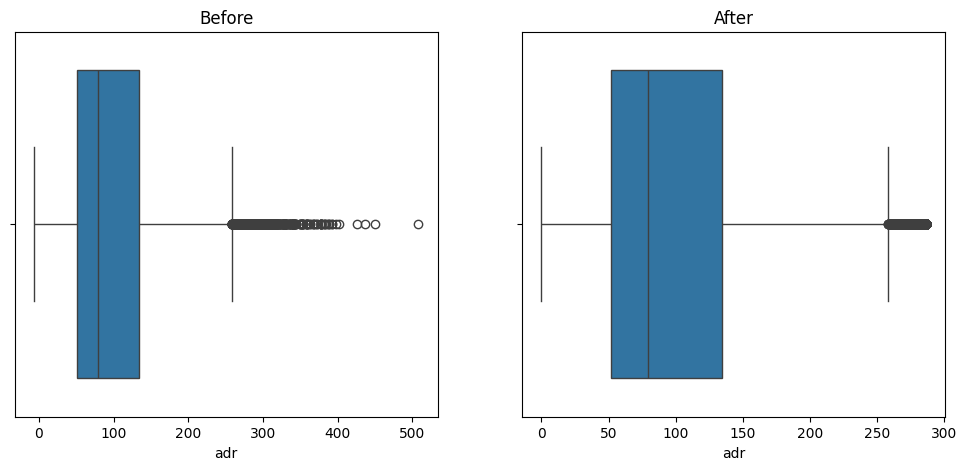

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['adr'])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(x=df_cleanednegative['adr'])
plt.title("After")

plt.show()

## 9. Save Clean Dataset

In [63]:
df_cleanednegative.to_csv('cleaned_data.csv', index=False) 